In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)


In [4]:
 data=pd.read_csv("cancer.csv")
 data

,Class,age,menopause,tumor-size,inv-nodes,node-caps,deg-malig,breast,breast-quad,irradiat
0,0,5,1,1,1,2,1,3,1,1
1,0,5,4,4,5,7,10,3,2,1
2,0,3,1,1,1,2,2,3,1,1
3,0,6,8,8,1,3,4,3,7,1
4,0,4,1,1,3,2,1,3,1,1
...,...,...,...,...,...,...,...,...,...,...
677,0,3,1,1,1,2,1,2,1,2
678,0,3,1,1,1,3,2,1,1,1
679,0,2,1,1,1,2,1,1,1,1
680,1,5,10,10,3,7,3,8,10,2


In [16]:
x=data[["age","menopause","tumor-size","inv-nodes","node-caps","deg-malig","breast","breast-quad","irradiat"]]
y=data["Class"]

In [17]:
print(x.columns)

Index(['age', 'menopause', 'tumor-size', 'inv-nodes', 'node-caps', 'deg-malig',
       'breast', 'breast-quad', 'irradiat'],
      dtype='object')


In [18]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [22]:
model=DecisionTreeClassifier(
    criterion="entropy",
    max_depth=4,
    random_state=42
)
model.fit(x_train, y_train)
y_pred=model.predict(x_test)

In [24]:
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)

cm=confusion_matrix(y_test,y_pred)
print("Confusion Matrix:\n",cm)

print(classification_report(y_test,y_pred))
print("Classification Report:\n")

Accuracy: 0.9562043795620438
Confusion Matrix:
 [[77  3]
 [ 3 54]]
              precision    recall  f1-score   support

           0       0.96      0.96      0.96        80
           1       0.95      0.95      0.95        57

    accuracy                           0.96       137
   macro avg       0.95      0.95      0.95       137
weighted avg       0.96      0.96      0.96       137

Classification Report:



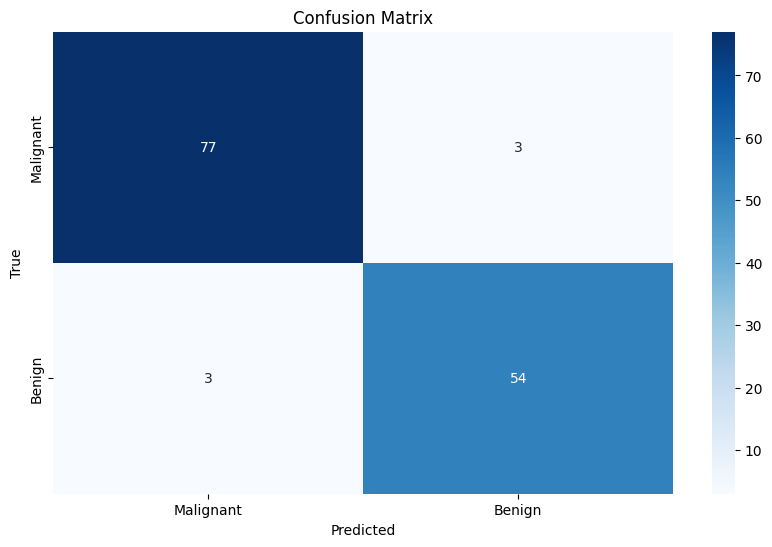

In [27]:
plt.figure(figsize=(10,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=['Malignant','Benign'],
    yticklabels=['Malignant','Benign']
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [35]:
import pandas as pd
feature_names = [
     'age','menopause','tumor-size','inv-nodes',
      'node-caps','deg-malig','breast','breast-quad',
      'irradiat'
]

user_data=[]

for feature in feature_names:
     value=input(f"Enter value for {feature}:")
     user_data.append(value)

new_patient=pd.DataFrame([user_data],columns=feature_names)

prediction=model.predict(new_patient)

if prediction[0]==1:
     print("Prediction:Malignant")
else:
     print("Prediction:Benign")

Enter value for age:41
Enter value for menopause:4
Enter value for tumor-size:4
Enter value for inv-nodes:5
Enter value for node-caps:7
Enter value for deg-malig:10
Enter value for breast:3
Enter value for breast-quad:2
Enter value for irradiat:1
Prediction:Malignant


In [36]:
prediction = model.predict(new_patient)

labels = {0: 'Benign', 1: 'Malignant'}
print("Prediction:",labels[prediction[0]])

Prediction: Malignant
